In [6]:
import tensorflow as tf
print(tf.__version__)
import sklearn
print(sklearn.__version__)
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets

2.20.0
1.8.0


In [7]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
# Normalise pixel values to [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0
classes = np.unique(y_train)
print('Number of classes: ', len(classes))
print('Output classes: ', classes)
# Find number of training data and data shape
x_train.shape

Number of classes:  10
Output classes:  [0 1 2 3 4 5 6 7 8 9]


(60000, 28, 28)

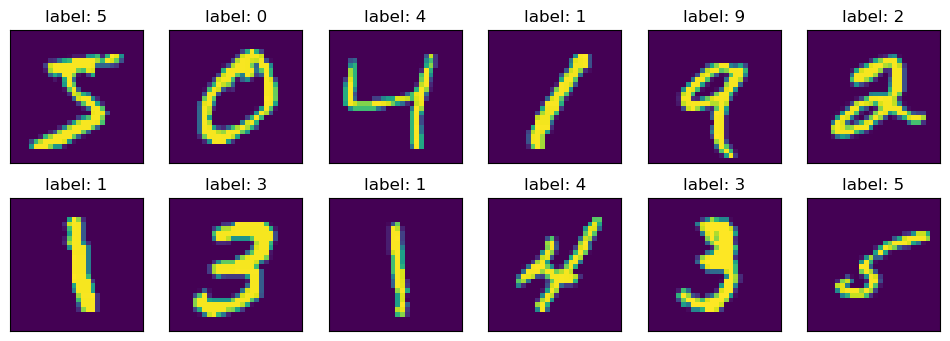

In [9]:
plt.figure(figsize=(12, 4))
for i in range(12): # show 12 images
    plt.subplot(2, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.title('label: '+str(y_train[i])) # label
plt.show()

In [14]:
from skimage.feature import hog
# Define our HOG feature extraction function
def extract_hog(images):
    features = []
    for img in images:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feat)
    return np.array(features)
# Extract HOG features for the train and test sets
X_train_hog = extract_hog(x_train[:])
X_test_hog = extract_hog(x_test[:])

In [15]:
# We'll use a linear kernel for efficiency, but feel free to use non-linear kernels in your own code
from sklearn import svm
clf_hog = svm.SVC(kernel='linear')
clf_hog.fit(X_train_hog, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


HOG + SVM Accuracy: 0.9767


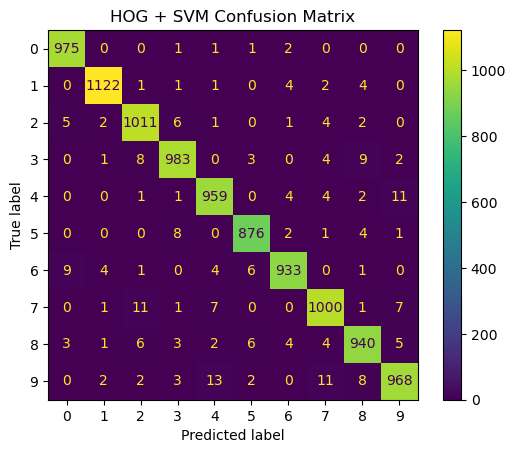

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Use the trained SVM classifier for prediction on test set
y_pred_hog = clf_hog.predict(X_test_hog)
# Compute and print accuracy
print("HOG + SVM Accuracy:", accuracy_score(y_test, y_pred_hog))
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_hog)
ConfusionMatrixDisplay(cm).plot()
plt.title("HOG + SVM Confusion Matrix")
plt.show()

In [18]:
import cv2
sift = cv2.SIFT_create()
# Define SIFT feature extraction function
def extract_sift(images):
    descriptors_list = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        _, descriptors = sift.detectAndCompute(img_uint8, None)
        if descriptors is not None:
            descriptors_list.extend(descriptors)
    return np.array(descriptors_list)
sift_descriptors = extract_sift(x_train[:10000])

In [19]:
from sklearn.cluster import MiniBatchKMeans
k = 50
kmeans = MiniBatchKMeans(n_clusters=k, random_state=0)
kmeans.fit(sift_descriptors)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",50
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",0
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [20]:
def build_histogram(images, kmeans):
    histograms = []
    for img in images:
        img_uint8 = (img * 255).astype(np.uint8)
        _, descriptors = sift.detectAndCompute(img_uint8, None)
        hist = np.zeros(k)
        if descriptors is not None:
            clusters = kmeans.predict(descriptors)
            for c in clusters:
                hist[c] += 1
        histograms.append(hist)
    return np.array(histograms)
X_train_sift = build_histogram(x_train[:10000], kmeans)
X_test_sift = build_histogram(x_test[:2000], kmeans)
y_train_sift = y_train[:10000]
y_test_sift = y_test[:2000]

SIFT + SVM Accuracy: 0.605


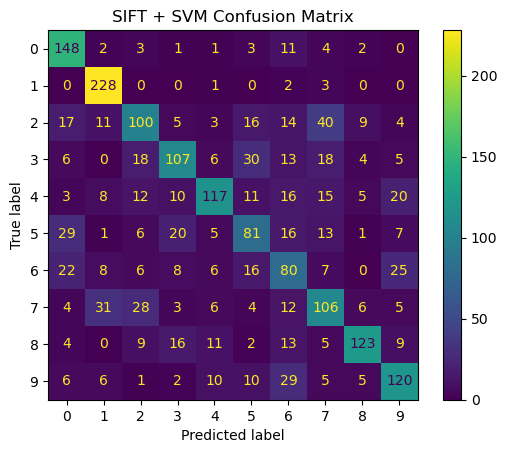

In [21]:
clf_sift = svm.SVC(kernel='linear')
clf_sift.fit(X_train_sift, y_train_sift)
# Prediction
y_pred_sift = clf_sift.predict(X_test_sift)
# Accuracy
print("SIFT + SVM Accuracy:", accuracy_score(y_test_sift, y_pred_sift))
# Confusion matrix
cm = confusion_matrix(y_test_sift, y_pred_sift)
ConfusionMatrixDisplay(cm).plot()
plt.title("SIFT + SVM Confusion Matrix")
plt.show()

In [23]:
import numpy as np
# Add channel dimension: (28,28) → (28,28,1)
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn = x_test[..., np.newaxis]
print("Training shape:", x_train_cnn.shape)

Training shape: (60000, 28, 28, 1)


In [24]:
from tensorflow.keras import layers, models
model = models.Sequential([
# First convolution block
layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),
# Second convolution block
layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),
# Classification head
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dense(10, activation='softmax')
])

/home/systems/miniconda3/envs/CVIA/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
x_train_cnn,
y_train,
epochs=5,
batch_size=64,
validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.9479 - loss: 0.1718 - val_accuracy: 0.9853 - val_loss: 0.0543
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9838 - loss: 0.0520 - val_accuracy: 0.9892 - val_loss: 0.0419
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.9893 - loss: 0.0342 - val_accuracy: 0.9875 - val_loss: 0.0461
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9915 - loss: 0.0259 - val_accuracy: 0.9900 - val_loss: 0.0335
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.9934 - loss: 0.0206 - val_accuracy: 0.9878 - val_loss: 0.0419


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9883 - loss: 0.0363
CNN Test Accuracy: 0.9883000254631042
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


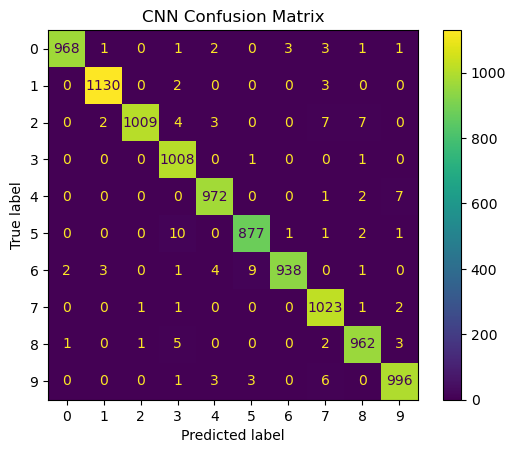

In [28]:
test_loss, test_acc = model.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc)
# Predictions on test set
y_pred_cnn = np.argmax(model.predict(x_test_cnn), axis=1)
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)
ConfusionMatrixDisplay(cm).plot()
plt.title("CNN Confusion Matrix")
plt.show()

In [29]:
incorrect_indices = np.where(y_pred_cnn != y_test)[0]
print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 117


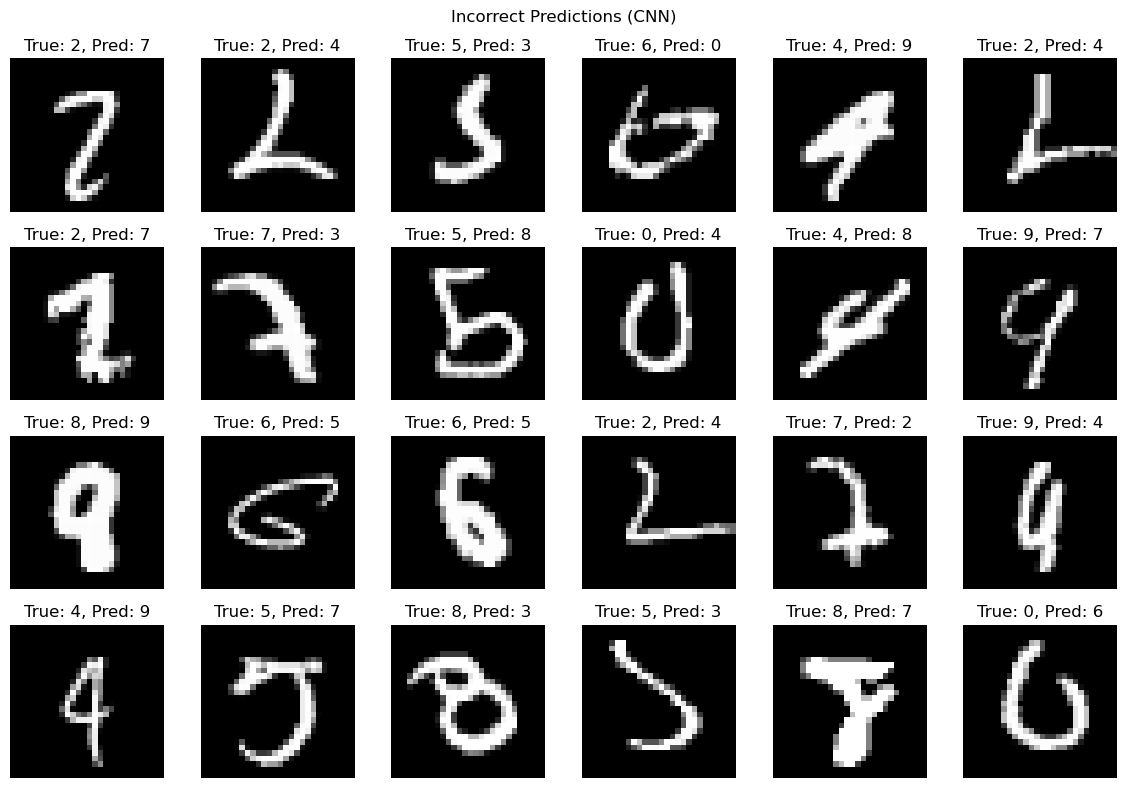

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(24):
    idx = incorrect_indices[i]
    plt.subplot(4, 6, i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_cnn[idx]}")
    plt.axis('off')
    plt.suptitle("Incorrect Predictions (CNN)")
    plt.tight_layout()
plt.show()